# 실습 3 | LangChain, LangGraph와 MCP

**학습 목표**
- 실습 1·2에서 직접 작성한 Tool Loop와 검증 Loop가 Framework에서 어떻게 표현되는지 확인한다.
- LangChain Agent의 Tool Call·Result, LangGraph의 State·Node·Edge·조건 분기, Checkpointer·Streaming을 관찰한다.
- 로컬 Tool과 외부 Wikidata MCP Tool의 연결 경로를 비교한다.

완성된 코드를 위에서 아래로 실행하는 실습입니다. 이 Notebook은 tools/ 외의 실행용 Python 파일이나 다른 실습 Notebook을 import하지 않습니다. 그래프 이미지는 가능한 경로이고, Streaming 기록은 이번 실행에서 실제로 지나간 경로입니다.


---
## 1. 실행 환경과 전시 안내문 과제

실제 실행에는 루트 .env의 OPENAI_API_KEY와 인터넷 연결이 필요합니다. 마지막 MCP 단계에서는 공개 Wikidata 서버에도 연결합니다.

실습 2와 같은 기획서·양식으로 제임스 웹 우주망원경 전시 안내문을 만듭니다. 기본 단계는 로컬 read_file과 한국어 위키백과 검색을, MCP 단계는 로컬 read_file과 외부 Wikidata search_items를 사용합니다.

> **실행 참고:** 모델의 답변, Tool 호출 순서와 검색 인자, LLM Evaluator의 판정, Feedback 및 Run 횟수는 실행마다 달라질 수 있습니다. 검증 규칙과 조건 분기 구조는 동일합니다.


In [43]:
import os
import re
import sys
import uuid
from collections.abc import Awaitable, Callable
from pathlib import Path
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "tools").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("저장소 루트 또는 workshop/ 폴더에서 Notebook을 실행하세요.")
sys.path.insert(0, str(PROJECT_ROOT))
from tools.read_file import read_file
from tools.wikipedia_search import wikipedia_search

load_dotenv(PROJECT_ROOT / ".env")
MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")
# Evaluator는 생성 모델과 독립적으로 바꿀 수 있도록 별도 상수로 둡니다.
EVALUATOR_MODEL = "gpt-4.1-mini"
MODEL_TIMEOUT = 30.0
WIKIPEDIA_TIMEOUT = 15.0
MAX_RUNS = 3
api_key = os.getenv("OPENAI_API_KEY", "")
if not api_key or api_key == "your-openai-api-key":
    raise RuntimeError("실행 전에 루트 .env에 OPENAI_API_KEY를 설정하세요.")

model = ChatOpenAI(model=MODEL, timeout=MODEL_TIMEOUT, max_retries=0)
evaluator_model = ChatOpenAI(model=EVALUATOR_MODEL, timeout=MODEL_TIMEOUT, max_retries=0)

# INSTRUCTIONS는 공통 작성 원칙이고, TASK는 이번 실행의 사용자 입력입니다.
INSTRUCTIONS = (
    "자료에 없는 관측 성과나 운영 정보를 지어내지 마세요. "
    "운영 정보는 기획서 문구를 그대로 쓰고 최종 답변에는 안내문만 출력하세요. "
    "더 알아보기 줄에는 마크다운 링크 없이 URL만 쓰세요. 예: - 🔎 더 알아보기: https://..."
)
TASK_BASE = (
    "workspace/space_note.md의 전시 기획서와 templates/exhibition_notice.md의 양식을 바탕으로 "
    "제임스 웹 우주망원경 전시 안내문 한 편을 작성해줘. "
    "필요한 사실과 한국어 위키백과 문서 링크를 확인해줘."
)
MCP_INSTRUCTIONS = (
    INSTRUCTIONS + " 이번 MCP 단계에서는 더 알아보기 항목에 외부 검색으로 확인한 "
    "Wikidata 항목 URL을 쓰고, 기억하거나 추측한 QID는 사용하지 마세요."
)
TASK_MCP = (
    "workspace/space_note.md의 전시 기획서와 templates/exhibition_notice.md의 양식을 바탕으로 "
    "제임스 웹 우주망원경 전시 안내문 한 편을 작성해줘. "
    "Wikidata에서 제임스 웹 우주망원경 항목을 확인하고, "
    "더 알아보기에는 확인된 Wikidata 문서 링크를 넣어줘."
)
print("Python:", sys.version.split()[0], "| Model:", MODEL, "| Max Runs:", MAX_RUNS)

Python: 3.12.14 | Model: gpt-4.1-mini | Max Runs: 3


> **결과 분석:** 출력에는 실행 중인 Python 버전, 생성 모델과 작성 시도 상한이 표시됩니다. `Max Runs: 3`은 안내문 작성 시도의 상한이며 모델·Tool 호출 횟수가 아닙니다.


---
## 2. LangChain Tool과 create_agent

직접 만든 Python 함수 두 개를 LangChain Tool로 감쌉니다. 
- 실습 2에서는 Schema와 Registry를 직접 관리했지만, 여기서는 Tool 객체를 Agent에 넘깁니다. 등록된 이름과 입력 Schema를 확인하세요.


In [44]:
@tool("read_file")
def read_file_tool(path: str) -> str:
    """Read a UTF-8 text file under the workshop repository."""
    return read_file(path)


@tool("wikipedia_search")
def wikipedia_search_tool(query: str) -> str:
    """Search Korean Wikipedia and return short descriptions and article URLs."""
    return wikipedia_search(query, timeout_seconds=WIKIPEDIA_TIMEOUT)


base_tools = [read_file_tool, wikipedia_search_tool]
for item in base_tools:
    print("[TOOL]", item.name, "| input:", item.args)

langchain_agent = create_agent(model=model, tools=base_tools, system_prompt=INSTRUCTIONS)
print("[AGENT]", type(langchain_agent).__name__)

[TOOL] read_file | input: {'path': {'title': 'Path', 'type': 'string'}}
[TOOL] wikipedia_search | input: {'query': {'title': 'Query', 'type': 'string'}}
[AGENT] CompiledStateGraph


> **결과 분석:** `[TOOL]`에는 등록한 Tool 이름과 입력 Schema가 표시되고, `[AGENT] CompiledStateGraph`는 생성된 Agent 객체의 타입을 보여줍니다. 아직 Tool 호출 결과가 출력된 것은 아닙니다.


---
## 3. LangChain Agent의 실제 Tool Loop

AIMessage의 Tool Call, ToolMessage의 결과, 다음 AIMessage를 순서대로 확인할 수 있습니다. 호출 순서는 코드에서 정하지 않습니다.


In [45]:
agent_result = langchain_agent.invoke(
    {"messages": [HumanMessage(content=TASK_BASE)]},
    config={"recursion_limit": 30},
)
for message in agent_result["messages"]:
    if isinstance(message, AIMessage) and message.tool_calls:
        for call in message.tool_calls:
            print("[TOOL CALL]", call["name"], call["args"])
    elif isinstance(message, ToolMessage):
        print("[TOOL RESULT]", message.name, str(message.content)[:10])
    elif isinstance(message, AIMessage):
        print("[📍FINAL ANSWER]\n", str(message.content)[:900])


[TOOL CALL] read_file {'path': 'workspace/space_note.md'}
[TOOL CALL] read_file {'path': 'templates/exhibition_notice.md'}
[TOOL CALL] wikipedia_search {'query': '제임스 웹 우주망원경'}
[TOOL RESULT] read_file # 제임스 웹 우주
[TOOL RESULT] read_file # 전시 안내문 작
[TOOL RESULT] wikipedia_search {"query": 
[📍FINAL ANSWER]
 # 보이지 않는 빛으로 우주를 보다

우리는 눈에 보이지 않는 빛으로 우주를 탐험할 수 있습니다.

제임스 웹 우주망원경은 2021년 12월 25일에 발사된 우주 망원경으로, 적외선이라는 눈에 보이지 않는 빛을 이용해 우주를 관측합니다. 적외선은 먼지에 가려 있거나 너무 어두워서 가시광선으로는 잘 보이지 않는 별과 은하, 행성들을 관찰할 수 있게 해줍니다. 이 망원경 덕분에 우리는 우주의 초기 모습과 태양계 너머의 신비한 세계를 더 깊이 이해할 수 있게 되었습니다.

이번 전시에서는 적외선 관측의 특별한 의미와 제임스 웹 우주망원경이 바라보는 우주를 쉽고 흥미롭게 소개합니다. 청소년과 일반 시민 모두에게 새로운 우주의 문을 열어줄 이번 전시에 여러분을 초대합니다.

- 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지  
- 📍 전시 장소: 우주과학 체험관 1층 특별전시실  
- 🍭 대상: 청소년과 일반 시민  
- ◯ 전시문의: workshop@example.com  
- 🔎 더 알아보기: https://science.nasa.gov/mission/webb/fact-sheet/


> **결과 분석:** `[TOOL CALL]`은 모델의 실행 요청, `[TOOL RESULT]`는 해당 Tool의 반환값, `[📍FINAL ANSWER]`는 모델이 작성한 안내문입니다. 이 출력에서 호출 요청과 실행 결과를 구분할 수 있습니다.


---
## 4. LangGraph State, Node, Edge와 조건 분기

> **독립 개념 예제:** 전시 안내문 Agent와 독립적으로, 숫자를 1씩 증가시키며 반복과 종료를 결정하는 간단한 Graph입니다.

각 구성 요소는 다음과 같습니다.

- **State — `CounterState`:** 현재 숫자인 `count`를 저장합니다.
- **Node — `increase`:** 현재 `count`에 1을 더한 값을 반환합니다.
- **Edge — `START → increase`:** Graph가 시작하면 `increase`를 실행합니다.
- **조건 함수 — `route_count`:** 증가한 `count`가 5 미만이면 `again`, 5 이상이면 `done`을 반환합니다.
- **Conditional Edge:** `again`이면 `increase`로 돌아가고, `done`이면 `END`로 이동합니다.

이 예제는 **Node가 State를 변경하고, 변경된 State에 따라 다음 실행 경로가 결정되는 과정**을 보여줍니다. 
<br>실습 2의 `while`과 `if`로 표현했던 반복·종료가 LangGraph에서 어떻게 표현되는지 확인하고, 뒤의 안내문 Agent에서 Tool 실행·검증·재작성 경로에 적용합니다.


In [46]:
class CounterState(TypedDict):
    count: int


def increase(state: CounterState) -> dict:
    """count를 1 늘린 State Update를 반환합니다."""
    return {"count": state["count"] + 1}


def route_count(state: CounterState) -> str:
    """count가 5 미만이면 "again", 아니면 "done"을 반환합니다."""
    return "again" if state["count"] < 5 else "done"


counter_builder = StateGraph(CounterState)
counter_builder.add_node("increase", increase)
counter_builder.add_edge(START, "increase")
counter_builder.add_conditional_edges(
    "increase", route_count, {"again": "increase", "done": END},
)
counter_graph = counter_builder.compile()
for update in counter_graph.stream({"count": 0}, stream_mode="updates"):
    print("[STATE UPDATE]", update)

[STATE UPDATE] {'increase': {'count': 1}}
[STATE UPDATE] {'increase': {'count': 2}}
[STATE UPDATE] {'increase': {'count': 3}}
[STATE UPDATE] {'increase': {'count': 4}}
[STATE UPDATE] {'increase': {'count': 5}}


> **결과 분석:** `[STATE UPDATE]`에 `increase` Node가 반환한 `count` 값이 1부터 5까지 출력됩니다. 이는 Node가 다섯 번 실행되며 State를 갱신한 결과입니다.


---
## 5. 실습 2의 검증 기준을 프레임워크 메시지에 적용

- 규칙 검증은 안내문의 필수 문구·관람 정보·단계별 링크 형식을 확인합니다. 
- Tool 검증은 성공한 ToolMessage와 그에 대응하는 Tool Call의 인자를 확인합니다. 
- `SOURCE_RULES`에는 현재 단계의 Wikipedia 링크, 검색 Tool, Evaluator 안내를 정의해 세 검증의 출처 기준을 일치시킵니다.


In [47]:
EXPECTED_TITLE = "# 보이지 않는 빛으로 우주를 보다"
REQUIRED_MARKERS = [
    "제임스 웹 우주망원경", "2021년", "적외선",
    "- 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지",
    "- 📍 전시 장소: 우주과학 체험관 1층 특별전시실",
    "- 🍭 대상: 청소년과 일반 시민",
    "- ◯ 전시문의: workshop@example.com",
]
INFO_LABELS = [
    "- 📅 전시 기간:", "- 📍 전시 장소:", "- 🍭 대상:",
    "- ◯ 전시문의:", "- 🔎 더 알아보기:",
]
REQUIRED_FILES = ("workspace/space_note.md", "templates/exhibition_notice.md")
SEARCH_TERMS = ("제임스웹", "jameswebb", "jwst")
TEMPLATE_RESIDUES = ("{", "}", "```")
SOURCE_RULES = {
    "wikipedia": {
        "label": "한국어 위키백과",
        "link_pattern": r"- 🔎 더 알아보기:\s*https://ko\.wikipedia\.org/wiki/\S+",
        "url_example": "https://ko.wikipedia.org/wiki/<문서명>",
        "search_tool": "wikipedia_search",
        "evaluator_guidance": (
            "이번 단계의 더 알아보기 링크는 한국어 위키백과 문서 URL입니다. "
            "다른 서비스의 링크로 바꾸라고 제안하지 마세요."
        ),
    },
}


def verify_notice(answer: str, source: str) -> list[str]:
    """안내문의 제목·필수 문구·관람 정보 순서·출처 링크·양식 흔적을 검사합니다.

    Args:
        answer: 검사할 안내문.
        source: SOURCE_RULES의 출처 키.

    Returns:
        발견한 문제 목록. 통과하면 빈 목록.
    """
    rule = SOURCE_RULES[source]
    lines = [line.strip() for line in answer.splitlines() if line.strip()]
    issues = []
    if not lines or lines[0] != EXPECTED_TITLE:
        issues.append(f"첫 줄 제목을 정확히 쓰세요: {EXPECTED_TITLE}")
    issues += [f"필수 문구 또는 관람 정보가 빠졌습니다: {marker}"
               for marker in REQUIRED_MARKERS if marker not in answer]
    positions = [answer.find(label) for label in INFO_LABELS]
    if min(positions) < 0 or positions != sorted(positions):
        issues.append("관람 정보 다섯 항목을 양식 순서대로 쓰세요.")
    if not re.search(rule["link_pattern"], answer):
        issues.append(
            f"더 알아보기 줄에 {rule['label']} URL을 마크다운 링크 없이 쓰세요. "
            f"예: - 🔎 더 알아보기: {rule['url_example']}"
        )
    if any(residue in answer for residue in TEMPLATE_RESIDUES):
        issues.append("양식의 중괄호 또는 코드 블록을 제거하세요.")
    return issues


def successful_calls(messages: list[AnyMessage]) -> list[dict]:
    """성공한 ToolMessage와 짝이 맞는 Tool Call만 골라냅니다.

    Args:
        messages: Agent 실행의 전체 메시지.

    Returns:
        성공적으로 실행된 Tool Call 목록.
    """
    completed_ids = {
        item.tool_call_id for item in messages
        if isinstance(item, ToolMessage) and item.status != "error"
    }
    return [
        call
        for item in messages if isinstance(item, AIMessage)
        for call in item.tool_calls if call["id"] in completed_ids
    ]


def verify_tool_messages(messages: list[AnyMessage], source: str) -> list[str]:
    """필수 파일 읽기와 지정 출처에서의 제임스 웹 우주망원경 검색 여부를 검사합니다.

    Args:
        messages: Agent 실행의 전체 메시지.
        source: SOURCE_RULES의 출처 키.

    Returns:
        누락된 Tool 사용 목록. 통과하면 빈 목록.
    """
    calls = successful_calls(messages)
    search_tool = SOURCE_RULES[source]["search_tool"]
    # read_file은 저장소 밖 경로를 거부하므로 성공한 호출의 경로는 항상 PROJECT_ROOT 안에 있습니다.
    read_paths = {
        (PROJECT_ROOT / call["args"]["path"]).resolve().relative_to(PROJECT_ROOT).as_posix()
        for call in calls
        if call["name"] == "read_file" and isinstance(call["args"].get("path"), str)
    }
    searched = any(
        term in re.sub(r"\s+", "", str(call["args"].get("query", ""))).lower()
        for call in calls if call["name"] == search_tool
        for term in SEARCH_TERMS
    )
    issues = [
        f"Tool로 읽은 기록이 없습니다: {path}" for path in REQUIRED_FILES if path not in read_paths
    ]
    if not searched:
        issues.append(f"{search_tool}에서 제임스 웹 우주망원경을 검색하세요.")
    return issues


print("[DIRECT AGENT TOOL CHECK]",
      verify_tool_messages(agent_result["messages"], "wikipedia") or "PASS")

[DIRECT AGENT TOOL CHECK] PASS


> **결과 분석:** `[DIRECT AGENT TOOL CHECK] PASS`는 두 필수 파일 읽기와 대상 검색의 성공 기록이 확인됐다는 뜻입니다. 안내문 형식이나 LLM 평가까지 통과했다는 뜻은 아닙니다.


---
## 6. 안내문을 평가하는 LLM Evaluator

생성 Agent가 작성한 안내문을 별도의 모델 호출로 평가합니다. Evaluator는 안내문을 다시 쓰지 않고, 기획서를 근거로 다음을 확인합니다.

- 청소년과 일반 시민이 적외선 관측의 이유를 쉽게 이해할 수 있는지
- 근거 없는 관측 성과나 운영 정보가 포함되어 있는지

평가 결과는 통과 여부인 `passed`와 수정할 점인 `feedback`으로 반환합니다. 문제가 없으면 `passed=True`와 빈 Feedback을 반환합니다.

링크 형식과 Tool 사용 여부는 5번의 검증 함수가 확인합니다. Evaluator에는 현재 단계의 출처 기준도 함께 전달하여, 지정한 출처를 다른 서비스로 바꾸라고 제안하지 않도록 안내합니다.

아래 셀에서는 평가 함수를 정의하며, 뒤의 Graph에서 `verify` Node가 이 함수를 호출합니다.


In [48]:
EVALUATOR_INSTRUCTIONS = (
    "당신은 전시 안내문의 평가자입니다. 안내문을 직접 다시 쓰지 마세요. "
    "기획서와 비교하여 청소년과 일반 시민이 적외선 관측의 이유를 이해할 수 있는지, "
    "근거 없는 구체적인 관측 성과나 운영 정보가 없는지 평가하세요. "
    "링크 형식과 Tool 사용은 별도 검증하므로 평가하지 마세요. "
    "명확한 개선점이 있을 때만 passed=false와 수정 가능한 feedback을 반환하세요. "
    "문제가 없으면 passed=true와 빈 feedback을 반환하세요."
)


class NoticeEvaluation(TypedDict):
    """전시 안내문 평가 결과."""
    passed: bool
    feedback: str


evaluator = evaluator_model.with_structured_output(NoticeEvaluation, strict=True)
# 기획서는 실행 중 바뀌지 않으므로 한 번만 읽어 모든 평가 호출에 재사용합니다.
SPACE_NOTE = read_file("workspace/space_note.md")


def evaluate_notice_with_llm(answer: str, source: str) -> tuple[bool, str]:
    """기획서와 출처 기준을 근거로 안내문의 명료성과 사실 근거를 LLM으로 평가합니다.

    Args:
        answer: 평가할 안내문.
        source: SOURCE_RULES의 출처 키.

    Returns:
        (통과 여부, 수정할 점) 튜플.
    """
    result = evaluator.invoke([
        SystemMessage(content=EVALUATOR_INSTRUCTIONS),
        HumanMessage(content=(
            f"전시 기획서:\n{SPACE_NOTE}\n\n"
            f"단계별 출처 기준:\n{SOURCE_RULES[source]['evaluator_guidance']}\n\n"
            f"평가할 안내문:\n{answer}"
        )),
    ])
    return result["passed"], result["feedback"].strip()


print("[DIRECT LLM EVALUATION]",
      evaluate_notice_with_llm(agent_result["messages"][-1].content, "wikipedia"))

[DIRECT LLM EVALUATION] (True, '')


---
## 7. 기본 LangGraph: Tool Loop와 Verification Loop

안내문 Agent의 Tool 실행과 검증·재작성 과정을 State, Node, 조건 분기로 연결한 기본 LangGraph를 구성합니다.

- **State:** `messages`는 모델과 Tool의 대화를 저장하고, `answer`·`passed`·`feedback`·`issues`는 안내문과 검증 결과를 저장합니다.
- **Tool Loop:** `agent`가 Tool을 요청하면 `tools`가 실행하고, 결과를 받은 `agent`가 다음 행동을 결정합니다.
- **Verification Loop:** 안내문이 나오면 `verify`가 검증하고, 실패하면 `feedback`이 수정할 점을 메시지에 추가하여 `agent`가 다시 작성하도록 합니다. 이전 안내문은 이미 `messages`에 있으므로 다시 넣지 않습니다.
- **종료 조건:** 검증을 통과하거나 `MAX_RUNS`에 도달하면 종료합니다. `iterations`는 안내문 작성 시도 횟수이며, Tool 호출 횟수가 아닙니다.
- **결과 재사용:** 같은 Graph 실행에서는 이전 Tool 결과가 `messages`에 남아 있으므로, Feedback 이후에도 다시 참고할 수 있습니다.
- **독립 실행:** 새 초기 State와 새 `thread_id`로 실행하면 이전 실행과 구분된 State를 사용합니다.
- **재사용 가능한 조립:** `build_notice_graph()`는 Agent Node·Tool·출처만 받아 위 구조를 조립하므로, 뒤의 MCP 단계에서도 그대로 씁니다.


In [49]:
class NoticeState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    answer: str
    passed: bool
    feedback: str
    iterations: int
    issues: list[str]


AgentNode = Callable[[NoticeState], dict | Awaitable[dict]]


def route_agent(state: NoticeState) -> str:
    """마지막 모델 메시지에 Tool Call이 있으면 "tools", 없으면 "verify"를 반환합니다."""
    last = state["messages"][-1]
    return "tools" if isinstance(last, AIMessage) and last.tool_calls else "verify"


def route_verify(state: NoticeState) -> str:
    """검증 통과 또는 반복 한도 도달이면 "end", 아니면 "feedback"을 반환합니다."""
    return "end" if state["passed"] or state["iterations"] >= MAX_RUNS else "feedback"


def feedback_node(state: NoticeState) -> dict:
    """검증 Feedback을 사용자 메시지로 추가하고 작성 시도 횟수를 늘립니다.

    이전 안내문은 이미 messages의 마지막 AIMessage로 남아 있으므로 다시 넣지 않습니다.

    Args:
        state: 현재 Graph State.

    Returns:
        새 사용자 메시지와 증가한 iterations를 담은 State Update.
    """
    return {
        "messages": [HumanMessage(content=state["feedback"])],
        "iterations": state["iterations"] + 1,
    }


def make_verification_feedback(issues: list[str]) -> str:
    """검증에서 발견한 문제를 다음 작성에 사용할 Feedback 문장으로 만듭니다.

    Args:
        issues: 검증에서 발견한 문제 목록.

    Returns:
        수정 요청 문장. 문제가 없으면 빈 문자열.
    """
    if not issues:
        return ""
    return "다음 문제를 고쳐 안내문을 다시 작성하세요:\n- " + "\n- ".join(issues)


def verify_state(state: NoticeState, source: str) -> dict:
    """Tool 기록·안내문 규칙·출처별 근거·LLM 평가를 결합해 검증 결과를 State에 반환합니다.

    Args:
        state: 현재 Graph State.
        source: SOURCE_RULES의 출처 키.

    Returns:
        answer·passed·feedback·issues를 담은 State Update.
    """
    answer = str(state["messages"][-1].content)
    tool_issues = verify_tool_messages(state["messages"], source)
    rule_issues = verify_notice(answer, source)
    # 출처별 추가 근거 검사는 SOURCE_RULES에 등록된 경우에만 실행합니다(12번 절의 Wikidata).
    evidence_check = SOURCE_RULES[source].get("evidence_check")
    evidence_issues = evidence_check(state["messages"], answer) if evidence_check else []
    llm_passed, llm_feedback = evaluate_notice_with_llm(answer, source)

    issues = [*tool_issues, *rule_issues, *evidence_issues]
    if not llm_passed:
        issues.append("LLM 평가: " + (llm_feedback or "설명을 다시 검토하세요."))
    feedback = make_verification_feedback(issues)

    print(
        "[VERIFY]", "PASS" if not issues else "FAIL",
        "| tool:", len(tool_issues), "rules:", len(rule_issues),
        "evidence:", len(evidence_issues), "LLM:", llm_passed,
    )
    if feedback:
        print("[FEEDBACK]", feedback[:650])
    return {"answer": answer, "passed": not issues, "feedback": feedback, "issues": issues}


def build_notice_graph(
    agent_node: AgentNode, tools: list[BaseTool], source: str
) -> CompiledStateGraph:
    """Tool Loop와 Verification Loop를 갖춘 안내문 Graph를 조립합니다.

    Args:
        agent_node: 모델을 호출하는 Node 함수(동기 또는 비동기).
        tools: ToolNode가 실행할 Tool 목록.
        source: 검증에 사용할 SOURCE_RULES의 출처 키.

    Returns:
        InMemorySaver Checkpointer를 연결해 컴파일한 Graph.
    """
    builder = StateGraph(NoticeState)
    builder.add_node("agent", agent_node)
    builder.add_node("tools", ToolNode(tools))
    builder.add_node("verify", lambda state: verify_state(state, source))
    builder.add_node("feedback", feedback_node)
    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", route_agent, {"tools": "tools", "verify": "verify"})
    builder.add_edge("tools", "agent")
    builder.add_conditional_edges("verify", route_verify, {"end": END, "feedback": "feedback"})
    builder.add_edge("feedback", "agent")
    return builder.compile(checkpointer=InMemorySaver())


base_model_with_tools = model.bind_tools(base_tools)


def base_agent_node(state: NoticeState) -> dict:
    """작성 원칙과 현재 대화를 모델에 전달하고 응답을 State에 추가합니다."""
    response = base_model_with_tools.invoke(
        [SystemMessage(content=INSTRUCTIONS), *state["messages"]]
    )
    return {"messages": [response]}


base_graph = build_notice_graph(base_agent_node, base_tools, "wikipedia")
print("[GRAPH NODES]", list(base_graph.get_graph().nodes))

[GRAPH NODES] ['__start__', 'agent', 'tools', 'verify', 'feedback', '__end__']


> **결과 분석:** `[GRAPH NODES]`에는 시작과 종료를 나타내는 `__start__`·`__end__`와 등록한 네 Node인 `agent`·`tools`·`verify`·`feedback`이 출력됩니다. 이는 Graph 구성이 완료되었다는 뜻이며, Node의 실행 순서나 실제 실행 경로를 보여주는 출력은 아닙니다.


---
## 8. 기본 Graph의 가능한 경로를 이미지로 보기

아래 그림은 조건에 따라 갈 수 있는 모든 경로를 보여줍니다. 실제 실행에서 어떤 경로를 지났는지는 뒤의 Streaming 출력으로 확인합니다.


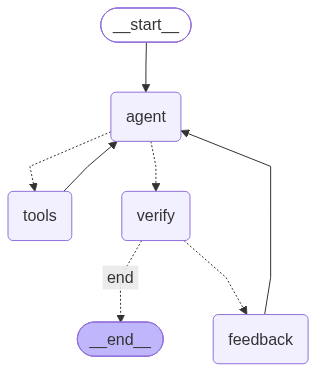

In [50]:
display(Image(base_graph.get_graph().draw_mermaid_png()))


---
## 9. Verification 실패와 재실행 경로 확인

> **모의 Graph 예제:** 별도로 구성한 작은 Graph에서 실제 안내문 규칙 검증기와 미리 작성한 안내문으로 검증 실패 → Feedback → 재작성 → 통과 경로를 확인합니다.

실제 모델이 첫 시도에서 통과할 수도 있으므로, 검증 분기를 작은 모의 Graph로 재현합니다. 
- 첫 안내문은 필수 항목이 빠져 실패하고, Feedback 뒤 두 번째 안내문은 통과합니다. 이 예시는 API를 호출하지 않습니다.


In [51]:
SAMPLE_NOTICE = """# 보이지 않는 빛으로 우주를 보다

눈에 보이지 않는 빛으로 우주를 살펴보세요.

제임스 웹 우주망원경은 2021년에 발사된 적외선 관측 망원경입니다. 적외선은 먼지에 가린 별의 형성 지역과 먼 은하를 살피는 데 도움을 줍니다. 전시에서는 가시광선과 적외선 관측의 차이를 비교합니다.

관측하는 빛이 바꾸는 우주의 모습을 만나보세요.

- 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지
- 📍 전시 장소: 우주과학 체험관 1층 특별전시실
- 🍭 대상: 청소년과 일반 시민
- ◯ 전시문의: workshop@example.com
- 🔎 더 알아보기: https://ko.wikipedia.org/wiki/제임스_웹_우주망원경
"""
INCOMPLETE_NOTICE = SAMPLE_NOTICE.replace("- ◯ 전시문의: workshop@example.com\n", "")


class DemoState(TypedDict):
    attempt: int
    answer: str
    passed: bool
    feedback: str


def demo_agent(state: DemoState) -> dict:
    """첫 시도에는 누락된 안내문을, 이후에는 완성된 안내문을 반환합니다."""
    return {"answer": INCOMPLETE_NOTICE if state["attempt"] == 1 else SAMPLE_NOTICE}


def demo_verify(state: DemoState) -> dict:
    """규칙 검증만으로 통과 여부와 Feedback을 정합니다."""
    issues = verify_notice(state["answer"], "wikipedia")
    return {"passed": not issues, "feedback": ", ".join(issues)}


def demo_feedback(state: DemoState) -> dict:
    """Feedback을 출력하고 작성 시도 번호를 늘립니다."""
    print("[DEMO FEEDBACK]", state["feedback"][:130])
    return {"attempt": state["attempt"] + 1}


demo_builder = StateGraph(DemoState)
demo_builder.add_node("agent", demo_agent)
demo_builder.add_node("verify", demo_verify)
demo_builder.add_node("feedback", demo_feedback)
demo_builder.add_edge(START, "agent")
demo_builder.add_edge("agent", "verify")
demo_builder.add_conditional_edges(
    "verify", lambda state: "end" if state["passed"] else "feedback",
    {"end": END, "feedback": "feedback"},
)
demo_builder.add_edge("feedback", "agent")
demo_graph = demo_builder.compile()
for update in demo_graph.stream({"attempt": 1, "answer": "", "passed": False, "feedback": ""},
                                stream_mode="updates"):
    print("[DEMO PATH]", next(iter(update)), update)

[DEMO PATH] agent {'agent': {'answer': '# 보이지 않는 빛으로 우주를 보다\n\n눈에 보이지 않는 빛으로 우주를 살펴보세요.\n\n제임스 웹 우주망원경은 2021년에 발사된 적외선 관측 망원경입니다. 적외선은 먼지에 가린 별의 형성 지역과 먼 은하를 살피는 데 도움을 줍니다. 전시에서는 가시광선과 적외선 관측의 차이를 비교합니다.\n\n관측하는 빛이 바꾸는 우주의 모습을 만나보세요.\n\n- 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지\n- 📍 전시 장소: 우주과학 체험관 1층 특별전시실\n- 🍭 대상: 청소년과 일반 시민\n- 🔎 더 알아보기: https://ko.wikipedia.org/wiki/제임스_웹_우주망원경\n'}}
[DEMO PATH] verify {'verify': {'passed': False, 'feedback': '필수 문구 또는 관람 정보가 빠졌습니다: - ◯ 전시문의: workshop@example.com, 관람 정보 다섯 항목을 양식 순서대로 쓰세요.'}}
[DEMO FEEDBACK] 필수 문구 또는 관람 정보가 빠졌습니다: - ◯ 전시문의: workshop@example.com, 관람 정보 다섯 항목을 양식 순서대로 쓰세요.
[DEMO PATH] feedback {'feedback': {'attempt': 2}}
[DEMO PATH] agent {'agent': {'answer': '# 보이지 않는 빛으로 우주를 보다\n\n눈에 보이지 않는 빛으로 우주를 살펴보세요.\n\n제임스 웹 우주망원경은 2021년에 발사된 적외선 관측 망원경입니다. 적외선은 먼지에 가린 별의 형성 지역과 먼 은하를 살피는 데 도움을 줍니다. 전시에서는 가시광선과 적외선 관측의 차이를 비교합니다.\n\n관측하는 빛이 바꾸는 우주의 모습을 만나보세요.\n\n- 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지\n- 📍 전시 장소: 우주과학 체험관 1층 특별전시실\n- 🍭 대상: 청소년과 일반 시민\n- ◯ 전

> **결과 분석:** `[DEMO PATH]`에는 `agent → verify → feedback → agent → verify`가 출력됩니다. 첫 검증은 `passed=False`이고, `attempt`가 2로 증가한 뒤 두 번째 검증은 `passed=True`입니다.


---
## 10. 기본 Graph 실행: Streaming과 Checkpointer

- Streaming의 updates는 실행 중 완료된 Node와 State Update를 순서대로 전달합니다. 
- Tool Call/Result, verify 판정, 최종 State를 확인하세요. 
- Checkpointer는 같은 thread_id의 State를 저장합니다.


In [52]:
def initial_state(task: str) -> NoticeState:
    """사용자 요청을 담고 검증·반복 관리 값을 초기화한 시작 State를 만듭니다.

    Args:
        task: 첫 사용자 요청.

    Returns:
        Graph 실행에 넘길 초기 State.
    """
    return {
        "messages": [HumanMessage(content=task)],
        "answer": "", "passed": False, "feedback": "",
        "iterations": 1, "issues": [],
    }


def show_update(update: dict) -> None:
    """Streaming으로 받은 Node별 State 변경에서 Tool 호출·결과·답변·검증 판정을 출력합니다.

    Args:
        update: stream_mode="updates"가 전달한 {Node 이름: State 변경}.
    """
    for node, change in update.items():
        print("[STREAM]", node)
        for message in change.get("messages", []):
            if isinstance(message, AIMessage) and message.tool_calls:
                calls = [(call["name"], call["args"]) for call in message.tool_calls]
                print("  [TOOL CALL]", calls)
            elif isinstance(message, ToolMessage):
                print("  [TOOL RESULT]", message.name)
            elif isinstance(message, AIMessage):
                print("  [ANSWER]", str(message.content)[:180])
        if node == "verify":
            print("  [VERIFICATION]", "PASS" if change["passed"] else "FAIL")


base_config = {
    "configurable": {"thread_id": "lab3-basic-" + uuid.uuid4().hex},
    "recursion_limit": 50,
}
for update in base_graph.stream(initial_state(TASK_BASE), base_config, stream_mode="updates"):
    show_update(update)

base_snapshot = base_graph.get_state(base_config)
print("[CHECKPOINT] next:", base_snapshot.next)
print("[FINAL STATUS]", "PASS" if base_snapshot.values["passed"] else "NOT PASSED",
      "| runs:", base_snapshot.values["iterations"])
print("[FINAL ANSWER]\n", base_snapshot.values["answer"])

[STREAM] agent
  [TOOL CALL] [('read_file', {'path': 'workspace/space_note.md'}), ('read_file', {'path': 'templates/exhibition_notice.md'}), ('wikipedia_search', {'query': '제임스 웹 우주망원경'})]
[STREAM] tools
  [TOOL RESULT] read_file
  [TOOL RESULT] read_file
  [TOOL RESULT] wikipedia_search
[STREAM] agent
  [ANSWER] # 보이지 않는 빛으로 우주를 보다

우주를 탐험하는 새로운 눈, 적외선 망원경의 세계에 오신 것을 환영합니다.

제임스 웹 우주망원경은 2021년 12월 25일에 발사된 최첨단 우주망원경으로, 적외선 빛을 이용해 우주의 깊은 곳을 관측합니다. 적외선은 우리 눈에 보이지 않는 빛이지만, 먼지 속에 가려진 별과 멀리 있는 
[VERIFY] FAIL | tool: 0 rules: 2 evidence: 0 LLM: True
[FEEDBACK] 다음 문제를 고쳐 안내문을 다시 작성하세요:
- 필수 문구 또는 관람 정보가 빠졌습니다: - 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지
- 더 알아보기 줄에 한국어 위키백과 URL을 마크다운 링크 없이 쓰세요. 예: - 🔎 더 알아보기: https://ko.wikipedia.org/wiki/<문서명>
[STREAM] verify
  [VERIFICATION] FAIL
[STREAM] feedback
[STREAM] agent
  [ANSWER] # 보이지 않는 빛으로 우주를 보다

우주를 탐험하는 새로운 눈, 적외선 망원경의 세계에 오신 것을 환영합니다.

제임스 웹 우주망원경은 2021년 12월 25일에 발사된 최첨단 우주망원경으로, 적외선 빛을 이용해 우주의 깊은 곳을 관측합니다. 적외선은 우리 눈에 보이지 않는 빛이지만, 먼지 속에 가려진 별과 멀리 있는

> **결과 분석:** `[STREAM]`은 업데이트를 반환한 Node를, `[VERIFY]`는 검증 결과를 보여줍니다. `tool`·`rules`·`evidence`의 숫자는 각각 Tool 사용·안내문 규칙·출처 근거(MCP 단계의 Wikidata QID)에서 발견된 문제 수이며, `[CHECKPOINT] next: ()`는 대기 중인 다음 Node가 없다는 뜻입니다. 최종 통과 여부와 작성 시도 횟수는 `[FINAL STATUS]`에서 확인합니다.


> **고찰 — `NOT PASSED`가 반복되던 원인:** 검증 규칙이 Harness 코드에만 있고 모델이 읽는
> 지시문에는 없으면, Agent는 실패 이유를 알 수 없어 같은 답을 반복하다 반복 한도에서 끝납니다.

> **원인.** 이전 실행에서 실패한 검사는 5번 절 `link_pattern` 하나였습니다(당시 `[VERIFY]` 출력에서 `rules`만 1이고 `tool`은 0, `LLM`은 `True`).
콜론 뒤에 URL이 바로 와야 하는데 안내문은 `[제목](URL)` 마크다운 링크였습니다. 이 조건은 모델이
받는 메시지 어디에도 없었고, Feedback도 "링크를 넣으세요"뿐이라 이미 링크를 넣은 모델은 고칠
지점을 알 수 없었습니다. 그래서 세 Run이 같은 답을 내고 `MAX_RUNS`에 걸렸습니다.

> **적용한 해결.**
1. **Feedback 구체화** — 5번 절 `verify_notice`의 링크 Feedback이 판정 조건을 그대로 알려줍니다:
   "마크다운 링크 없이 URL만, 예: `- 🔎 더 알아보기: https://...`". Loop를 수렴시키는 핵심입니다.
2. **지시문에 규칙 명시** — 1번 절 `INSTRUCTIONS`에 같은 규칙을 넣었습니다.
   `MCP_INSTRUCTIONS`는 `INSTRUCTIONS`를 이어 쓰므로 MCP 단계에도 적용됩니다.

---
## 11. MCP 실행 전 확인

외부 Wikidata MCP 서버에 연결합니다. 별도 로컬 MCP 서버나 인증 설정은 만들지 않습니다. 
- LangChain MCPAdapter가 서버에서 Tool 이름·설명·입력 Schema를 발견하는지 확인하고, 읽기 전용 search_items만 선택합니다. 
- 서버 연결이 실패하면 여기서 오류를 확인합니다. 
- 기본 양식의 위키백과 링크 지시는 MCP 단계의 Wikidata 링크 지시로 바꿔 적용합니다.

> **실행 참고:** MCP 서버의 검색 결과와 순서는 실행 시점에 따라 달라질 수 있습니다.


In [53]:
from langchain.mcp import MCPAdapter

WIKIDATA_MCP_URL = "https://wd-mcp.wmcloud.org/mcp"
async with MCPAdapter(WIKIDATA_MCP_URL) as adapter:
    discovered_tools = await adapter.list_tools()

for item in discovered_tools:
    print("[MCP TOOL]", item.name, "| input:", item.args,
          "| description:", item.description.splitlines()[0])
mcp_search_tool = next((item for item in discovered_tools if item.name == "search_items"), None)
if mcp_search_tool is None:
    raise RuntimeError("Wikidata MCP 서버에서 search_items를 발견하지 못했습니다.")
print("[SELECTED]", mcp_search_tool.name)

[MCP TOOL] search_items | input: {'query': {'type': 'string'}, 'lang': {'default': 'en', 'type': 'string'}} | description: Search Wikidata items (QIDs) using semantic and keyword search.
[MCP TOOL] search_properties | input: {'query': {'type': 'string'}, 'lang': {'default': 'en', 'type': 'string'}, 'include_external_ids': {'default': False, 'type': 'boolean'}} | description: Search Wikidata properties (PIDs) using semantic and keyword search.
[MCP TOOL] get_statements | input: {'entity_id': {'type': 'string'}, 'include_external_ids': {'default': False, 'type': 'boolean'}, 'lang': {'default': 'en', 'type': 'string'}} | description: Retrieve direct statements (property-value pairs) for a Wikidata entity.
[MCP TOOL] get_statement_values | input: {'entity_id': {'type': 'string'}, 'property_id': {'type': 'string'}, 'lang': {'default': 'en', 'type': 'string'}} | description: Return full detailed values for an entity-property statement pair, including qualifiers, references, and all ranks.
[M

> **결과 분석:** `[MCP TOOL]`에는 서버에서 발견한 Tool의 이름·입력 Schema·설명 첫 줄이 표시됩니다. `[SELECTED] search_items`는 발견한 목록에서 항목 검색 Tool을 선택했다는 뜻이며, 아직 실제 검색 결과는 아닙니다.


---
## 12. 별도 MCP Graph 구성과 이미지

- `SOURCE_RULES["wikidata"]`에 MCP 단계의 링크, 검색 Tool, Evaluator 안내를 추가하고 기본 Graph와 같은 `build_notice_graph()`로 MCP Graph를 조립합니다. 
- Agent·ToolNode에는 read_file과 발견한 search_items만 제공하며, verify_state와 feedback_node는 기본 Graph와 공유합니다. 링크 검증은 `evidence_check`로 등록한 `verify_wikidata_evidence`가 Wikidata QID와 검색 결과의 일치 여부까지 확인합니다.


In [54]:
def verify_wikidata_evidence(messages: list[AnyMessage], answer: str) -> list[str]:
    """안내문의 Wikidata QID가 성공한 search_items 결과에 실제로 있었는지 확인합니다.

    Args:
        messages: Agent 실행의 전체 메시지.
        answer: 검사할 안내문.

    Returns:
        근거가 없으면 문제 한 건, 있거나 링크가 없으면 빈 목록.
    """
    link = re.search(r"https://www\.wikidata\.org/wiki/(Q\d+)", answer)
    if link is None:
        return []
    # 단어 경계가 없으면 Q123이 Q1234 검색 결과와도 일치해 버립니다.
    qid_pattern = rf"\b{link.group(1)}\b"
    found = any(
        re.search(qid_pattern, str(item.content))
        for item in messages
        if isinstance(item, ToolMessage)
        and item.name == "search_items"
        and item.status != "error"
    )
    return [] if found else ["안내문의 Wikidata QID가 search_items 결과에 없습니다."]


SOURCE_RULES["wikidata"] = {
    "label": "Wikidata",
    "link_pattern": r"- 🔎 더 알아보기:\s*https://www\.wikidata\.org/wiki/Q\d+",
    "url_example": "https://www.wikidata.org/wiki/<QID>",
    "search_tool": "search_items",
    "evidence_check": verify_wikidata_evidence,
    "evaluator_guidance": (
        "이번 단계의 더 알아보기 링크는 외부 검색으로 확인한 Wikidata QID URL입니다. "
        "한국어 위키백과 링크로 바꾸라고 제안하지 마세요."
    ),
}

mcp_tools = [read_file_tool, mcp_search_tool]
mcp_model_with_tools = model.bind_tools(mcp_tools)


async def mcp_agent_node(state: NoticeState) -> dict:
    """MCP 단계 작성 원칙과 현재 대화를 모델에 비동기로 전달합니다."""
    response = await mcp_model_with_tools.ainvoke(
        [SystemMessage(content=MCP_INSTRUCTIONS), *state["messages"]]
    )
    return {"messages": [response]}


mcp_graph = build_notice_graph(mcp_agent_node, mcp_tools, "wikidata")
print("[MCP GRAPH NODES]", list(mcp_graph.get_graph().nodes))

[MCP GRAPH NODES] ['__start__', 'agent', 'tools', 'verify', 'feedback', '__end__']


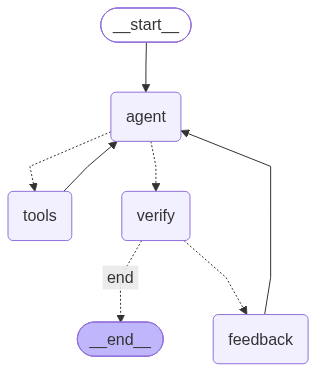

In [55]:
display(Image(mcp_graph.get_graph().draw_mermaid_png()))


> **결과 분석:** `[MCP GRAPH NODES]`와 이미지에는 기본 Graph와 같은 Node·Edge 구성이 나타납니다. 이미지에는 ToolNode 내부의 Tool 이름이나 실행 위치가 표시되지 않습니다.


---
## 13. MCP Graph 실제 실행 경로

같은 안내문 과제를 다시 수행하되, 외부 항목 검색과 더 알아보기 링크는 Wikidata MCP 서버가 제공합니다. 
- 전시 기획과 양식은 로컬 read_file로 읽습니다. 
- Tool을 단순히 등록하는 것으로 끝내지 않고 search_items의 호출·결과, 다음 모델 판단, 검증 판정을 확인합니다.


In [56]:
mcp_config = {
    "configurable": {"thread_id": "lab3-mcp-" + uuid.uuid4().hex},
    "recursion_limit": 50,
}
async for update in mcp_graph.astream(initial_state(TASK_MCP), mcp_config, stream_mode="updates"):
    show_update(update)

mcp_snapshot = await mcp_graph.aget_state(mcp_config)
print("[MCP FINAL STATUS]", "PASS" if mcp_snapshot.values["passed"] else "NOT PASSED",
      "| runs:", mcp_snapshot.values["iterations"])
print("[MCP TOOL CHECK]",
      verify_tool_messages(mcp_snapshot.values["messages"], "wikidata") or "PASS")
print("[MCP FINAL ANSWER]\n", mcp_snapshot.values["answer"])


[STREAM] agent
  [TOOL CALL] [('read_file', {'path': 'workspace/space_note.md'}), ('read_file', {'path': 'templates/exhibition_notice.md'}), ('search_items', {'query': 'James Webb Space Telescope', 'lang': 'ko'})]
[STREAM] tools
  [TOOL RESULT] read_file
  [TOOL RESULT] read_file
  [TOOL RESULT] search_items
[STREAM] agent
  [ANSWER] # 보이지 않는 빛으로 우주를 보다

우주는 보이지 않는 빛, 적외선으로도 탐험할 수 있습니다.

제임스 웹 우주망원경은 2021년에 발사된 최신 우주 천문대입니다. 이 망원경은 적외선 빛을 이용해 먼 우주의 먼지에 가려 잘 보이지 않는 천체들을 관찰합니다. 적외선은 가시광선과 달리 먼지와 기체를 투과해 초기 우주의 은하
[VERIFY] FAIL | tool: 0 rules: 1 evidence: 0 LLM: True
[FEEDBACK] 다음 문제를 고쳐 안내문을 다시 작성하세요:
- 필수 문구 또는 관람 정보가 빠졌습니다: - 📅 전시 기간: 2027년 5월 1일부터 5월 31일까지
[STREAM] verify
  [VERIFICATION] FAIL
[STREAM] feedback
[STREAM] agent
  [ANSWER] # 보이지 않는 빛으로 우주를 보다

우주는 보이지 않는 빛, 적외선으로도 탐험할 수 있습니다.

제임스 웹 우주망원경은 2021년에 발사된 최신 우주 천문대입니다. 이 망원경은 적외선 빛을 이용해 먼 우주의 먼지에 가려 잘 보이지 않는 천체들을 관찰합니다. 적외선은 가시광선과 달리 먼지와 기체를 투과해 초기 우주의 은하
[VERIFY] PASS | tool: 0 rules: 0 evidence: 0 LLM: True
[STREAM] verify

> **결과 분석:** `[STREAM]`에는 로컬 파일 읽기와 외부 항목 검색의 호출·결과가 표시됩니다. `[MCP FINAL STATUS]`는 종합 검증 결과와 작성 시도 횟수이고, `[MCP TOOL CHECK]`는 필수 Tool 사용 검사 결과입니다. `[MCP FINAL ANSWER]`에는 최종 안내문과 Wikidata 링크가 출력됩니다.


> **고찰:** 기본 Graph와 MCP Graph의 제어 구조를 유지하면서 제공하는 Tool을 바꿀 수 있습니다. 이 비교는 LangGraph의 실행 흐름 관리와 MCP의 외부 Tool 연결이 서로 다른 역할임을 보여줍니다.


---
## 전체 정리

실습 1·2의 직접 Tool Registry와 반복문은 LangChain Agent·LangGraph ToolNode와 Edge로, 결과 검증과 재실행은 verify·feedback Node와 Conditional Edge로 나타났습니다. Checkpointer는 State를 저장하고 Streaming은 실제 실행 경로를 보여줍니다. 같은 Graph 실행의 messages는 Feedback Loop에서도 유지되며, MCP는 Agent Loop를 바꾸지 않고 Tool의 제공 경로를 외부 서버까지 확장했습니다.

참고: [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents), [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api), [LangChain MCP](https://docs.langchain.com/oss/python/langchain/mcp), [Wikidata MCP](https://github.com/wmde/WikidataMCP)
